Load and filter to trustworthy labels

In [1]:
# === Load data & keep only rows with a trustworthy start label ===
import pandas as pd

df = pd.read_parquet("data/history/all_seasons_fixed.parquet")
model_df = df[df["starts"].notna()].copy()

print("Rows for modeling:", len(model_df))
print("Start rate:", round(model_df["starts"].mean(), 3))

Rows for modeling: 105101
Start rate: 0.29


Collapse double gameweeks to one row per player-GW, Minutes are summed

In [2]:
# === Collapse double-GWs: one row per (season, element, GW), flag doubles ===
key = ["season", "element", "GW"]

model_df = model_df.sort_values(key).reset_index(drop=True)
model_df["is_double_gw"] = (
    model_df.groupby(key)["minutes"].transform("size") > 1
).astype(int)

agg_rules = {
    "minutes": "sum",         # total minutes across both matches
    "total_points": "sum",    # total points across both matches
    "starts": "max",          # "started at least one" -> 0/1
    "is_double_gw": "max",
}
for col in model_df.columns:
    if col not in key and col not in agg_rules:
        agg_rules[col] = "first"

collapsed = model_df.groupby(key, as_index=False).agg(agg_rules)

print("Rows after collapse:", len(collapsed))
print("Double-GWs flagged :", collapsed["is_double_gw"].sum())
assert collapsed.groupby(key).size().max() == 1, "Grain broken: >1 row per player-GW"

Rows after collapse: 101777
Double-GWs flagged : 3324


Making the Wave 1 Features

In [3]:
# === Wave 1 features: recent starts & minutes history (all as-of, no leakage) ===
collapsed = collapsed.sort_values(["season", "element", "GW"]).reset_index(drop=True)

# For minutes-FORM features, cap at 90 so double-GWs (135/180) don't distort
# the average above a single match. The true 'minutes' column stays untouched.
collapsed["minutes_capped"] = collapsed["minutes"].clip(upper=90)

grp = collapsed.groupby(["season", "element"])

# started_last_gw: did they start the previous GW? (shift already row-aligned)
collapsed["started_last_gw"] = grp["starts"].shift(1)

# Helper: for a column, compute rolling stat over PRIOR gameweeks only.
# shift(1) inside the group first, then roll. transform() keeps row alignment.
def rolling_prior(col, window, how):
    def f(s):
        return s.shift(1).rolling(window, min_periods=1).agg(how)
    return grp[col].transform(f)

collapsed["starts_last3"] = rolling_prior("starts", 3, "sum")
collapsed["starts_last5"] = rolling_prior("starts", 5, "sum")
collapsed["avg_min_last3"] = rolling_prior("minutes_capped", 3, "mean")
collapsed["avg_min_last5"] = rolling_prior("minutes_capped", 5, "mean")

feat_cols = ["started_last_gw", "starts_last3", "starts_last5", "avg_min_last3", "avg_min_last5"]
print(collapsed[feat_cols].describe())

       started_last_gw  starts_last3  starts_last5  avg_min_last3  \
count     98489.000000  98489.000000  98489.000000   98489.000000   
mean          0.292845      0.851141      1.372722      26.309392   
std           0.455070      1.197111      1.873851      34.791521   
min           0.000000      0.000000      0.000000       0.000000   
25%           0.000000      0.000000      0.000000       0.000000   
50%           0.000000      0.000000      0.000000       0.000000   
75%           1.000000      2.000000      3.000000      58.666667   
max           1.000000      3.000000      5.000000      90.000000   

       avg_min_last5  
count   98489.000000  
mean       26.351235  
std        33.629117  
min         0.000000  
25%         0.000000  
50%         2.600000  
75%        54.200000  
max        90.000000  


In [4]:
# Salah is element 283 in 2022-23. Show label + all 5 features together.
view_cols = ["season", "GW", "element", "starts",
             "started_last_gw", "starts_last3", "starts_last5",
             "avg_min_last3", "avg_min_last5"]

salah = collapsed[(collapsed["element"] == 283) & (collapsed["season"] == "2022-23")]
salah[view_cols].head(12)

,season,GW,element,starts,started_last_gw,starts_last3,starts_last5,avg_min_last3,avg_min_last5
6329,2022-23,16,283,1.0,NaN,NaN,NaN,NaN,NaN
6330,2022-23,17,283,1.0,1.0,1.0,1.0,90.000000,90.0
6331,2022-23,18,283,1.0,1.0,2.0,2.0,90.000000,90.0
6332,2022-23,19,283,1.0,1.0,3.0,3.0,90.000000,90.0
6333,2022-23,20,283,1.0,1.0,3.0,4.0,90.000000,90.0
6334,2022-23,21,283,1.0,1.0,3.0,5.0,90.000000,90.0
6335,2022-23,22,283,1.0,1.0,3.0,5.0,90.000000,90.0
6336,2022-23,23,283,1.0,1.0,3.0,5.0,90.000000,90.0
6337,2022-23,24,283,1.0,1.0,3.0,5.0,89.666667,89.8
6338,2022-23,25,283,1.0,1.0,3.0,5.0,89.666667,89.8


Wave 1 Feature Description

In [5]:
feat_cols = ["started_last_gw", "starts_last3", "starts_last5",
             "avg_min_last3", "avg_min_last5"]

# 1. What does each feature look like? (min, max, average, spread)
print("=== Summary of each feature ===")
print(collapsed[feat_cols].describe().round(2).T)

# 2. How many missing values? (the 'no history yet' rows)
print("\n=== Missing values per feature ===")
print(collapsed[feat_cols].isna().sum())

# 3. A few real example rows so you can SEE actual values
print("\n=== 10 random real rows (features + the label) ===")
print(collapsed[["name", "season", "GW"] + feat_cols + ["starts"]]
      .dropna(subset=feat_cols)
      .sample(10, random_state=1)
      .to_string(index=False))

=== Summary of each feature ===
                   count   mean    std  min  25%  50%    75%   max
started_last_gw  98489.0   0.29   0.46  0.0  0.0  0.0   1.00   1.0
starts_last3     98489.0   0.85   1.20  0.0  0.0  0.0   2.00   3.0
starts_last5     98489.0   1.37   1.87  0.0  0.0  0.0   3.00   5.0
avg_min_last3    98489.0  26.31  34.79  0.0  0.0  0.0  58.67  90.0
avg_min_last5    98489.0  26.35  33.63  0.0  0.0  2.6  54.20  90.0

=== Missing values per feature ===
started_last_gw    3288
starts_last3       3288
starts_last5       3288
avg_min_last3      3288
avg_min_last5      3288
dtype: int64

=== 10 random real rows (features + the label) ===
                             name  season  GW  started_last_gw  starts_last3  starts_last5  avg_min_last3  avg_min_last5  starts
                   Mohammed Kudus 2024-25  25              1.0           3.0           5.0      90.000000           80.6     1.0
Murillo Santiago Costa dos Santos 2023-24  21              1.0           3.0           

Dropped 3288 rows with no histry, GW1 of the respective seasons, will be handled later

In [6]:
# === Assemble the modeling table: label + features ===
label = "starts"
feat_cols = ["started_last_gw", "starts_last3", "starts_last5",
             "avg_min_last3", "avg_min_last5", "is_double_gw"]

# Keep identity columns too (for splitting + inspection later), then drop no-history rows
keep = ["season", "GW", "element", "name", label] + feat_cols
data = collapsed[keep].dropna(subset=feat_cols).reset_index(drop=True)

print("Final modeling table shape:", data.shape)
print("Rows dropped (no history):", len(collapsed) - len(data))
print("\nStart rate in final table:", round(data[label].mean(), 3))
print("\nRows per season:")
print(data.groupby("season").size())

Final modeling table shape: (98489, 11)
Rows dropped (no history): 3288

Start rate in final table: 0.292

Rows per season:
season
2022-23    15688
2023-24    27877
2024-25    26427
2025-26    28497
dtype: int64


Train Test Split but keeping the Time component in mind

In [7]:
# === Walk-forward split by season: train on past, validate/test on future ===
train = data[data["season"].isin(["2022-23", "2023-24"])]
val   = data[data["season"] == "2024-25"]
test  = data[data["season"] == "2025-26"]

print("Train :", len(train), "rows (2022-23, 2023-24)")
print("Val   :", len(val),   "rows (2024-25)")
print("Test  :", len(test),  "rows (2025-26)  <- do NOT touch until the end")

for name, d in [("train", train), ("val", val), ("test", test)]:
    print(f"  {name} start rate:", round(d["starts"].mean(), 3))

Train : 43565 rows (2022-23, 2023-24)
Val   : 26427 rows (2024-25)
Test  : 28497 rows (2025-26)  <- do NOT touch until the end
  train start rate: 0.292
  val start rate: 0.304
  test start rate: 0.282


Fitting LR

In [8]:
# === Fit the first P(start) model: logistic regression ===
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

feat_cols = ["started_last_gw", "starts_last3", "starts_last5",
             "avg_min_last3", "avg_min_last5", "is_double_gw"]

X_train, y_train = train[feat_cols], train["starts"]
X_val,   y_val   = val[feat_cols],   val["starts"]

# Scale: fit on TRAIN only, then apply the same transform to val (no leakage)
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_val_s   = scaler.transform(X_val)

# Train logistic regression
model = LogisticRegression(max_iter=1000)
model.fit(X_train_s, y_train)

# Predict PROBABILITIES on validation (column 1 = P(start))
val_probs = model.predict_proba(X_val_s)[:, 1]

print("Model trained.")
print("First 10 predicted P(start):", val_probs[:10].round(3))
print("Their actual starts        :", y_val.values[:10])

Model trained.
First 10 predicted P(start): [0.039 0.039 0.039 0.039 0.039 0.039 0.039 0.039 0.039 0.039]
Their actual starts        : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


Predictions 

In [9]:
import numpy as np

print("Spread of predicted P(start) across ALL validation rows:")
print("  min :", round(val_probs.min(), 3))
print("  25% :", round(np.percentile(val_probs, 25), 3))
print("  50% :", round(np.percentile(val_probs, 50), 3))
print("  75% :", round(np.percentile(val_probs, 75), 3))
print("  max :", round(val_probs.max(), 3))

# How many distinct-ish prediction levels are there?
print("\nRows predicted >0.8 (confident start):", (val_probs > 0.8).sum())
print("Rows predicted <0.1 (confident bench):", (val_probs < 0.1).sum())

Spread of predicted P(start) across ALL validation rows:
  min : 0.016
  25% : 0.039
  50% : 0.057
  75% : 0.651
  max : 0.987

Rows predicted >0.8 (confident start): 5288
Rows predicted <0.1 (confident bench): 15126


Calibration Score for the LR Model

Brier score (lower = better)
  Our model : 0.0894
  Baseline  : 0.2118 (always guess the base rate)

    bin  n_rows  avg_predicted  actual_started    gap
0.0-0.1   15126          0.044           0.032 -0.011
0.1-0.2    1513          0.142           0.256  0.115
0.2-0.3     908          0.246           0.360  0.114
0.3-0.4     712          0.349           0.475  0.126
0.4-0.5     695          0.458           0.511  0.053
0.5-0.6     532          0.551           0.602  0.051
0.6-0.7     759          0.652           0.648 -0.004
0.7-0.8     894          0.752           0.742 -0.011
0.8-0.9    1820          0.850           0.818 -0.032
0.9-1.0    3468          0.930           0.917 -0.014


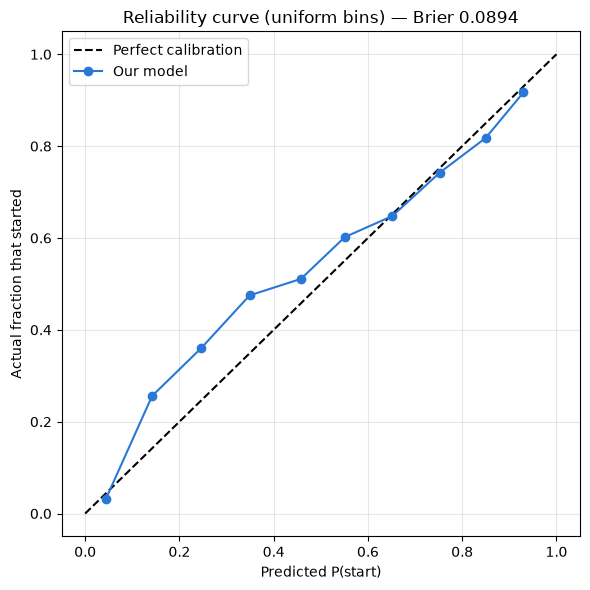

In [10]:
import matplotlib.pyplot as plt
# === Calibration check: Brier score + reliability curve (uniform bins) ===
from sklearn.metrics import brier_score_loss

# --- Brier score: our model vs the "always guess the base rate" baseline ---
brier_model    = brier_score_loss(y_val, val_probs)
baseline_probs = np.full(len(y_val), y_train.mean())
brier_baseline = brier_score_loss(y_val, baseline_probs)

print("Brier score (lower = better)")
print("  Our model :", round(brier_model, 4))
print("  Baseline  :", round(brier_baseline, 4), "(always guess the base rate)")
print()

# --- Reliability table with uniform (equal-width) bins ---
edges = np.arange(0, 1.1, 0.1)
idx = np.clip(np.digitize(val_probs, edges) - 1, 0, 9)

rows = []
for b in range(10):
    m = idx == b
    if m.sum() == 0:
        continue
    rows.append({
        "bin":            f"{edges[b]:.1f}-{edges[b+1]:.1f}",
        "n_rows":         int(m.sum()),
        "avg_predicted":  round(val_probs[m].mean(), 3),
        "actual_started": round(y_val.values[m].mean(), 3),
        "gap":            round(y_val.values[m].mean() - val_probs[m].mean(), 3),
    })

tbl = pd.DataFrame(rows)
print(tbl.to_string(index=False))

# --- Plot ---
plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
plt.plot(tbl["avg_predicted"], tbl["actual_started"], "o-", color="#2a78d6", label="Our model")
plt.xlabel("Predicted P(start)")
plt.ylabel("Actual fraction that started")
plt.title(f"Reliability curve (uniform bins) — Brier {brier_model:.4f}")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Fitting LightBGM Model on Wave 1 features

In [11]:
# === LightGBM P(start) model — same features, same split ===
import lightgbm as lgb
from sklearn.metrics import brier_score_loss

feat_cols = ["started_last_gw", "starts_last3", "starts_last5",
             "avg_min_last3", "avg_min_last5", "is_double_gw"]

X_train, y_train = train[feat_cols], train["starts"]
X_val,   y_val   = val[feat_cols],   val["starts"]

lgb_model = lgb.LGBMClassifier(
    n_estimators=300,      # number of trees
    learning_rate=0.05,    # how much each tree corrects (smaller = slower, safer)
    num_leaves=31,         # tree complexity
    random_state=42,
    verbose=-1,
)
lgb_model.fit(X_train, y_train)

lgb_probs = lgb_model.predict_proba(X_val)[:, 1]

print("Brier score comparison (lower = better)")
print("  Logistic regression :", round(brier_score_loss(y_val, val_probs), 4))
print("  LightGBM            :", round(brier_score_loss(y_val, lgb_probs), 4))
print("  Baseline            :", round(brier_score_loss(y_val, np.full(len(y_val), y_train.mean())), 4))

Brier score comparison (lower = better)
  Logistic regression : 0.0894
  LightGBM            : 0.0882
  Baseline            : 0.2118


LR vs LightBGM Analysis

In [12]:
# Did LightGBM fix the 0.1-0.4 miscalibration band?
edges = np.arange(0, 1.1, 0.1)
idx = np.clip(np.digitize(lgb_probs, edges) - 1, 0, 9)

rows = []
for b in range(10):
    m = idx == b
    if m.sum() == 0:
        continue
    rows.append({
        "bin": f"{edges[b]:.1f}-{edges[b+1]:.1f}",
        "n_rows": int(m.sum()),
        "avg_predicted": round(lgb_probs[m].mean(), 3),
        "actual_started": round(y_val.values[m].mean(), 3),
        "gap": round(y_val.values[m].mean() - lgb_probs[m].mean(), 3),
    })
print(pd.DataFrame(rows).to_string(index=False))

    bin  n_rows  avg_predicted  actual_started    gap
0.0-0.1   13634          0.019           0.020  0.001
0.1-0.2    1835          0.146           0.169  0.023
0.2-0.3    1320          0.245           0.267  0.022
0.3-0.4     895          0.348           0.413  0.065
0.4-0.5     765          0.457           0.441 -0.016
0.5-0.6     680          0.557           0.557 -0.000
0.6-0.7    1066          0.650           0.634 -0.016
0.7-0.8    1542          0.751           0.739 -0.012
0.8-0.9    2154          0.853           0.857  0.004
0.9-1.0    2536          0.930           0.928 -0.002


Wave 2 Features

In [13]:
# === Wave 2 features: injury proxies + role ===
collapsed = collapsed.sort_values(["season", "element", "GW"]).reset_index(drop=True)
grp = collapsed.groupby(["season", "element"])

# --- Injury proxy 1: consecutive 0-minute GWs immediately before this one ---
def zero_run(s):
    prior = s.shift(1)                       # only look backwards
    is_zero = (prior == 0).astype(float)
    # running count of consecutive zeros, resets when they play
    grp_id = (is_zero == 0).cumsum()
    return is_zero.groupby(grp_id).cumsum()

collapsed["consec_zero_mins"] = grp["minutes"].transform(zero_run)

# --- Injury proxy 2: gameweeks since their last START ---
def gws_since_start(s):
    prior = s.shift(1)
    started = (prior == 1)
    grp_id = started.cumsum()                # increments each time they start
    # count rows since the last start within each block
    return prior.groupby(grp_id).cumcount()

collapsed["gws_since_last_start"] = grp["starts"].transform(gws_since_start)

# --- Injury proxy 3: recent minutes vs longer baseline (falling off a cliff?) ---
prior_min = grp["minutes_capped"].shift(1)
recent  = prior_min.rolling(2, min_periods=1).mean()
baseline = prior_min.rolling(8, min_periods=2).mean()
collapsed["minutes_trend"] = (recent - baseline).values

# --- Role features (already in the table, no computation needed) ---
# position is categorical -> convert to numeric codes for the model
collapsed["position_code"] = collapsed["position"].astype("category").cat.codes

wave2 = ["consec_zero_mins", "gws_since_last_start", "minutes_trend",
         "position_code", "value"]
print(collapsed[wave2].describe().round(2).T)

                         count   mean    std    min    25%   50%   75%     max
consec_zero_mins      101777.0   6.67   9.44   0.00   0.00   2.0  11.0   37.00
gws_since_last_start  101777.0   8.14   9.88   0.00   0.00   4.0  14.0   37.00
minutes_trend         101765.0   0.00  19.79 -77.14  -2.25   0.0   1.5   77.14
position_code         101777.0   2.65   1.34   0.00   1.00   3.0   4.0    4.00
value                 101777.0  48.72  10.74   5.00  43.00  45.0  51.0  154.00


Removed Rows with Manager as Position

In [14]:
# === Remove Assistant Manager (AM) rows — not players, don't belong in a minutes model ===
before = len(collapsed)
collapsed = collapsed[collapsed["position"] != "AM"].reset_index(drop=True)
print("Rows removed (AM):", before - len(collapsed))
print("Positions now:", collapsed["position"].unique())
print("Min value now:", collapsed["value"].min(), "(should be >= 35)")

# Rebuild position_code now that AM is gone (so codes are 0-3, not 0-4)
collapsed["position_code"] = collapsed["position"].astype("category").cat.codes
print("Position codes:", sorted(collapsed["position_code"].unique()))

Rows removed (AM): 312
Positions now: <ArrowStringArray>
['DEF', 'GK', 'MID', 'FWD']
Length: 4, dtype: str
Min value now: 36 (should be >= 35)
Position codes: [np.int8(0), np.int8(1), np.int8(2), np.int8(3)]


Wave 2 Features after cleaning

In [15]:
# === Wave 2 features: injury proxies + role (both trend windows) ===
collapsed = collapsed.sort_values(["season", "element", "GW"]).reset_index(drop=True)
grp = collapsed.groupby(["season", "element"])

# Proxy 1: run of consecutive 0-minute GWs immediately before now
def zero_run(s):
    prior = s.shift(1)
    is_zero = (prior == 0).astype(float)
    blocks = (is_zero == 0).cumsum()
    return is_zero.groupby(blocks).cumsum()

collapsed["consec_zero_mins"] = grp["minutes"].transform(zero_run)

# Proxy 2: gameweeks since their last START
def gws_since_start(s):
    prior = s.shift(1)
    blocks = (prior == 1).cumsum()
    return prior.groupby(blocks).cumcount()

collapsed["gws_since_last_start"] = grp["starts"].transform(gws_since_start)

# Proxy 3: recent vs baseline minutes — TWO variants to compare
def trend(window):
    def f(s):
        prior = s.shift(1)
        return prior.rolling(window, min_periods=1).mean() - prior.rolling(8, min_periods=2).mean()
    return grp["minutes_capped"].transform(f)

collapsed["minutes_trend_2"] = trend(2)
collapsed["minutes_trend_3"] = trend(3)

# Role
collapsed["position_code"] = collapsed["position"].astype("category").cat.codes

wave2 = ["consec_zero_mins", "gws_since_last_start",
         "minutes_trend_2", "minutes_trend_3", "position_code", "value"]
print(collapsed[wave2].describe().round(2).T)

                         count   mean    std    min    25%   50%   75%     max
consec_zero_mins      101465.0   6.67   9.45   0.00   0.00   2.0  11.0   37.00
gws_since_last_start  101465.0   8.14   9.90   0.00   0.00   4.0  14.0   37.00
minutes_trend_2        94940.0  -0.14  16.30 -67.50  -0.25   0.0   0.0   67.50
minutes_trend_3        94940.0  -0.11  12.89 -56.25   0.00   0.0   0.0   56.25
position_code         101465.0   1.66   1.33   0.00   0.00   2.0   3.0    3.00
value                 101465.0  48.84  10.53  36.00  43.00  45.0  51.0  154.00


Combine Wave 1 and 2 Features

In [16]:
# === Assemble with Wave 1 + Wave 2, test both trend windows ===
import lightgbm as lgb
from sklearn.metrics import brier_score_loss

base_feats = ["started_last_gw", "starts_last3", "starts_last5",
              "avg_min_last3", "avg_min_last5", "is_double_gw",
              "consec_zero_mins", "gws_since_last_start",
              "position_code", "value"]

results = {}
for trend_col in ["minutes_trend_2", "minutes_trend_3"]:
    feats = base_feats + [trend_col]
    keep = ["season", "GW", "element", "name", "starts"] + feats
    d = collapsed[keep].dropna(subset=feats).reset_index(drop=True)

    tr = d[d["season"].isin(["2022-23", "2023-24"])]
    va = d[d["season"] == "2024-25"]

    m = lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05,
                           num_leaves=31, random_state=42, verbose=-1)
    m.fit(tr[feats], tr["starts"])
    p = m.predict_proba(va[feats])[:, 1]
    results[trend_col] = brier_score_loss(va["starts"], p)
    print(f"{trend_col}: Brier {results[trend_col]:.4f}  (train {len(tr)}, val {len(va)})")

print("\nWave 1 only (6 features) was: 0.0882")
print("Winner:", min(results, key=results.get))

minutes_trend_2: Brier 0.0880  (train 41929, val 25354)
minutes_trend_3: Brier 0.0877  (train 41929, val 25354)

Wave 1 only (6 features) was: 0.0882
Winner: minutes_trend_3


Wave 1 vs Wave 2 Features Caliberation numbers

In [17]:
# === Refit stage 1 classifier with a clear name ===
s1_feats = ["started_last_gw", "starts_last3", "starts_last5",
            "avg_min_last3", "avg_min_last5", "is_double_gw",
            "consec_zero_mins", "gws_since_last_start",
            "position_code", "value", "minutes_trend_3"]

keep = ["season", "starts"] + s1_feats
d1 = collapsed[keep].dropna(subset=s1_feats).reset_index(drop=True)
tr1 = d1[d1["season"].isin(["2022-23", "2023-24"])]
va1 = d1[d1["season"] == "2024-25"]

model_pstart = lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05,
                                  num_leaves=31, random_state=42, verbose=-1)
model_pstart.fit(tr1[s1_feats], tr1["starts"])

p1_check = model_pstart.predict_proba(va1[s1_feats])[:, 1]
print("Stage 1 refit — Brier:", round(brier_score_loss(va1["starts"], p1_check), 4),
      "(should be ~0.0877)")

Stage 1 refit — Brier: 0.0877 (should be ~0.0877)


Ablation Tests

In [18]:
# === Ablation: do the start-history features earn their place? ===
full_feats = base_feats + ["minutes_trend_3"]
drop_feats = [f for f in full_feats
              if f not in ["started_last_gw", "starts_last3", "starts_last5"]]

def run(feats, label):
    keep = ["season", "starts"] + feats
    d = collapsed[keep].dropna(subset=feats).reset_index(drop=True)
    tr = d[d["season"].isin(["2022-23", "2023-24"])]
    va = d[d["season"] == "2024-25"]
    m = lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05,
                           num_leaves=31, random_state=42, verbose=-1)
    m.fit(tr[feats], tr["starts"])
    p = m.predict_proba(va[feats])[:, 1]
    b = brier_score_loss(va["starts"], p)

    # also check the middle band, since Brier hides things
    mid = (p >= 0.2) & (p < 0.5)
    mid_gap = va["starts"].values[mid].mean() - p[mid].mean()

    print(f"{label:28s} Brier {b:.4f}  | n_feats {len(feats):2d} | mid-band gap {mid_gap:+.3f}")
    return b

b_full = run(full_feats, "All 11 features")
b_drop = run(drop_feats, "Without start-history (8)")

print(f"\nDifference: {b_drop - b_full:+.5f}  (positive = dropping HURT)")

All 11 features              Brier 0.0877  | n_feats 11 | mid-band gap +0.015
Without start-history (8)    Brier 0.0881  | n_feats  8 | mid-band gap +0.011

Difference: +0.00042  (positive = dropping HURT)


STAGE 2: PREDICTING GIVEN A PLAYER STARTS WHAT IS THE PROBABILITY HE WILL PLAY AT LEAST 60 MINUTES

Filtering for players that started

In [19]:
# === Stage 2 dataset: only players who STARTED ===
started_df = collapsed[collapsed["starts"] == 1].copy()

print("Rows where player started:", len(started_df))

# The label: did they reach 60 minutes?
# Using minutes_capped (per-match ceiling of 90) not raw summed minutes.
started_df["played_60"] = (started_df["minutes_capped"] >= 60).astype(int)

print("P(60+ | started):", round(started_df["played_60"].mean(), 3))
print("\nLabel balance:")
print(started_df["played_60"].value_counts())

# Sanity: how do doubles differ? (capped vs raw could disagree here)
print("\n=== Double-GW rows: does capping change the label? ===")
dbl = started_df[started_df["is_double_gw"] == 1]
raw_label = (dbl["minutes"] >= 60).astype(int)
print("Double-GW rows:", len(dbl))
print("Disagreements between raw and capped label:", (raw_label != dbl["played_60"]).sum())

Rows where player started: 29722
P(60+ | started): 0.932

Label balance:
played_60
1    27708
0     2014
Name: count, dtype: int64

=== Double-GW rows: does capping change the label? ===
Double-GW rows: 1146
Disagreements between raw and capped label: 0


Featuring Building for it: we added only 3 more features to wave 2

In [20]:
# === Stage 2 feature: their own past rate of reaching 60+ when starting ===
started_df = started_df.sort_values(["season", "element", "GW"]).reset_index(drop=True)
g2 = started_df.groupby(["season", "element"])

# Rolling mean of played_60 over PRIOR starts only (shift first)
def prior_rate(window):
    def f(s):
        return s.shift(1).rolling(window, min_periods=1).mean()
    return g2["played_60"].transform(f)

started_df["past60_rate_3"] = prior_rate(3)
started_df["past60_rate_5"] = prior_rate(5)

# Also: minutes in their most recent start (were they hooked early last time?)
started_df["last_start_minutes"] = g2["minutes_capped"].shift(1)

new_feats = ["past60_rate_3", "past60_rate_5", "last_start_minutes"]
print(started_df[new_feats].describe().round(2).T)
print("\nNon-null counts (first start of each player-season will be NaN):")
print(started_df[new_feats].notna().sum())

                      count   mean    std  min   25%   50%   75%   max
past60_rate_3       27812.0   0.94   0.16  0.0   1.0   1.0   1.0   1.0
past60_rate_5       27812.0   0.94   0.14  0.0   1.0   1.0   1.0   1.0
last_start_minutes  27812.0  83.34  12.40  2.0  81.0  90.0  90.0  90.0

Non-null counts (first start of each player-season will be NaN):
past60_rate_3         27812
past60_rate_5         27812
last_start_minutes    27812
dtype: int64


Fitting the LightBGM Model

In [21]:
# === Stage 2 model: P(60+ | started) ===
s2_feats = ["past60_rate_3", "past60_rate_5", "last_start_minutes",
            "avg_min_last3", "avg_min_last5", "minutes_trend_3",
            "position_code", "value", "is_double_gw",
            "consec_zero_mins", "gws_since_last_start"]

keep = ["season", "played_60"] + s2_feats
d2 = started_df[keep].dropna(subset=s2_feats).reset_index(drop=True)

tr2 = d2[d2["season"].isin(["2022-23", "2023-24"])]
va2 = d2[d2["season"] == "2024-25"]
print("Train:", len(tr2), " Val:", len(va2))

m2 = lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05,
                        num_leaves=31, random_state=42, verbose=-1)
m2.fit(tr2[s2_feats], tr2["played_60"])
p2 = m2.predict_proba(va2[s2_feats])[:, 1]
y2 = va2["played_60"].values

print("\nBrier  model   :", round(brier_score_loss(y2, p2), 4))
print("Brier  baseline:", round(brier_score_loss(y2, np.full(len(y2), tr2['played_60'].mean())), 4),
      "(always predict the base rate)")
print("\nPrediction spread: min", round(p2.min(), 3), " max", round(p2.max(), 3))

Train: 11854  Val: 7575

Brier  model   : 0.0638
Brier  baseline: 0.0626 (always predict the base rate)

Prediction spread: min 0.16  max 1.0


Fitting the constrained model

In [22]:
# === Stage 2, attempt 2: constrained model + class weighting ===
baseline_brier = brier_score_loss(y2, np.full(len(y2), tr2['played_60'].mean()))

configs = {
    "original":              dict(n_estimators=300, num_leaves=31),
    "constrained":           dict(n_estimators=100, num_leaves=7, min_child_samples=100,
                                  reg_lambda=1.0),
    "constrained+weighted":  dict(n_estimators=100, num_leaves=7, min_child_samples=100,
                                  reg_lambda=1.0, scale_pos_weight=0.075),
}

for name, cfg in configs.items():
    m = lgb.LGBMClassifier(learning_rate=0.05, random_state=42, verbose=-1, **cfg)
    m.fit(tr2[s2_feats], tr2["played_60"])
    p = m.predict_proba(va2[s2_feats])[:, 1]
    print(f"{name:22s} Brier {brier_score_loss(y2, p):.4f}  "
          f"| spread {p.min():.3f}-{p.max():.3f}")

print(f"{'BASELINE (flat 0.93)':22s} Brier {baseline_brier:.4f}")

original               Brier 0.0638  | spread 0.160-1.000
constrained            Brier 0.0607  | spread 0.580-0.991
constrained+weighted   Brier 0.2061  | spread 0.169-0.938
BASELINE (flat 0.93)   Brier 0.0626


Analysis

In [23]:
# === Calibration check on the constrained stage 2 model ===
m2b = lgb.LGBMClassifier(n_estimators=100, num_leaves=7, min_child_samples=100,
                         reg_lambda=1.0, learning_rate=0.05, random_state=42, verbose=-1)
m2b.fit(tr2[s2_feats], tr2["played_60"])
p2b = m2b.predict_proba(va2[s2_feats])[:, 1]

edges = np.arange(0.5, 1.05, 0.05)   # narrower bins: predictions live in 0.58-0.99
idx = np.clip(np.digitize(p2b, edges) - 1, 0, len(edges) - 2)

rows = []
for b in range(len(edges) - 1):
    msk = idx == b
    if msk.sum() < 20:
        continue
    rows.append({"bin": f"{edges[b]:.2f}-{edges[b+1]:.2f}",
                 "n": int(msk.sum()),
                 "predicted": round(p2b[msk].mean(), 3),
                 "actual": round(y2[msk].mean(), 3),
                 "gap": round(y2[msk].mean() - p2b[msk].mean(), 3)})
print(pd.DataFrame(rows).to_string(index=False))

      bin    n  predicted  actual    gap
0.70-0.75   23      0.732   0.652 -0.080
0.75-0.80   89      0.781   0.876  0.096
0.80-0.85  427      0.831   0.864  0.033
0.85-0.90  872      0.879   0.866 -0.013
0.90-0.95 2838      0.931   0.927 -0.004
0.95-1.00 3308      0.967   0.970  0.002


PROBABILITY THAT A PLAYER WOULD START OFF THE BENCH

Filtering for players who did not start

In [24]:
# === P(appear | did not start): the missing piece ===
bench_df = collapsed[collapsed["starts"] == 0].copy()
bench_df["came_on"] = (bench_df["minutes"] > 0).astype(int)

print("Non-starter rows:", len(bench_df))
print("P(came on | did not start):", round(bench_df["came_on"].mean(), 3))
print("\nLabel balance:")
print(bench_df["came_on"].value_counts())

Non-starter rows: 71743
P(came on | did not start): 0.152

Label balance:
came_on
0    60812
1    10931
Name: count, dtype: int64


Same features as before, no new ones added, and fit on LightBGM

In [25]:
# === P(came on | did not start) ===
sub_feats = ["avg_min_last3", "avg_min_last5", "minutes_trend_3",
             "consec_zero_mins", "gws_since_last_start",
             "starts_last3", "starts_last5", "started_last_gw",
             "position_code", "value", "is_double_gw"]

keep = ["season", "came_on"] + sub_feats
d3 = bench_df[keep].dropna(subset=sub_feats).reset_index(drop=True)

tr3 = d3[d3["season"].isin(["2022-23", "2023-24"])]
va3 = d3[d3["season"] == "2024-25"]
print("Train:", len(tr3), " Val:", len(va3))

m3 = lgb.LGBMClassifier(n_estimators=200, num_leaves=15, min_child_samples=50,
                        learning_rate=0.05, random_state=42, verbose=-1)
m3.fit(tr3[sub_feats], tr3["came_on"])
p3 = m3.predict_proba(va3[sub_feats])[:, 1]
y3 = va3["came_on"].values

print("\nBrier model   :", round(brier_score_loss(y3, p3), 4))
print("Brier baseline:", round(brier_score_loss(y3, np.full(len(y3), tr3['came_on'].mean())), 4))
print("Spread:", round(p3.min(), 3), "to", round(p3.max(), 3))

Train: 29700  Val: 17553

Brier model   : 0.0899
Brier baseline: 0.14
Spread: 0.001 to 0.845


Analysis

In [26]:
imp = pd.DataFrame({"feature": sub_feats, "importance": m3.feature_importances_})
print(imp.sort_values("importance", ascending=False).to_string(index=False))

# Calibration
edges = np.arange(0, 1.05, 0.1)
idx = np.clip(np.digitize(p3, edges) - 1, 0, len(edges) - 2)
rows = []
for b in range(len(edges) - 1):
    msk = idx == b
    if msk.sum() < 20:
        continue
    rows.append({"bin": f"{edges[b]:.1f}-{edges[b+1]:.1f}", "n": int(msk.sum()),
                 "predicted": round(p3[msk].mean(), 3),
                 "actual": round(y3[msk].mean(), 3),
                 "gap": round(y3[msk].mean() - p3[msk].mean(), 3)})
print("\n" + pd.DataFrame(rows).to_string(index=False))

             feature  importance
               value         578
     minutes_trend_3         522
       avg_min_last5         375
    consec_zero_mins         332
       avg_min_last3         326
       position_code         253
gws_since_last_start         239
        starts_last5          72
        is_double_gw          54
        starts_last3          49
     started_last_gw           0

    bin     n  predicted  actual    gap
0.0-0.1 10645      0.020   0.025  0.004
0.1-0.2  1855      0.148   0.141 -0.007
0.2-0.3  1330      0.249   0.244 -0.005
0.3-0.4   831      0.344   0.374  0.030
0.4-0.5   849      0.449   0.489  0.039
0.5-0.6   778      0.547   0.598  0.050
0.6-0.7   815      0.655   0.693  0.038
0.7-0.8   438      0.733   0.740  0.007


SIMPLE REGRESSION TO PREDICT THE MINUTES OF A PLAYER WHEN HE STARTS

In [29]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
# === Retrain E[min|started] WITHOUT starter-only features ===
reg_feats_v2 = ["avg_min_last3", "avg_min_last5", "minutes_trend_3",
                "consec_zero_mins", "gws_since_last_start",
                "position_code", "value", "is_double_gw",
                "started_last_gw", "starts_last3", "starts_last5"]

keep = ["season", "minutes_capped"] + reg_feats_v2
d4b = started_df[keep].dropna(subset=reg_feats_v2).reset_index(drop=True)
tr4b = d4b[d4b["season"].isin(["2022-23", "2023-24"])]
va4b = d4b[d4b["season"] == "2024-25"]

m4b = lgb.LGBMRegressor(n_estimators=200, num_leaves=15, min_child_samples=50,
                        learning_rate=0.05, random_state=42, verbose=-1)
m4b.fit(tr4b[reg_feats_v2], tr4b["minutes_capped"])
p4b = m4b.predict(va4b[reg_feats_v2])
y4b = va4b["minutes_capped"].values

print("E[min|started] without starter-only features:")
print(f"  RMSE {np.sqrt(mean_squared_error(y4b,p4b)):.2f}  MAE {mean_absolute_error(y4b,p4b):.2f}")
print(f"  (with them was: RMSE 11.88  MAE 8.01)")
print(f"  Train rows: {len(tr4b)}  Val rows: {len(va4b)}")

E[min|started] without starter-only features:
  RMSE 11.99  MAE 8.16
  (with them was: RMSE 11.88  MAE 8.01)
  Train rows: 12229  Val rows: 7801


Total Players that got subbed on

In [30]:
# === Stage 3c: E[minutes | came on as sub] ===
subs_df = bench_df[bench_df["came_on"] == 1].copy()
print("Rows (non-starters who appeared):", len(subs_df))
print("Minutes distribution:")
print(subs_df["minutes_capped"].describe().round(1))

Rows (non-starters who appeared): 10931
Minutes distribution:
count    10931.0
mean        18.4
std         14.4
min          1.0
25%          7.0
50%         16.0
75%         26.0
max         90.0
Name: minutes_capped, dtype: float64


Probability that a player would come of the bench, given he is benched

In [31]:
# === Fit E[minutes | came on as sub] ===
sub_reg_feats = ["avg_min_last3", "avg_min_last5", "minutes_trend_3",
                 "consec_zero_mins", "gws_since_last_start",
                 "position_code", "value", "is_double_gw"]

keep = ["season", "minutes_capped"] + sub_reg_feats
d5 = subs_df[keep].dropna(subset=sub_reg_feats).reset_index(drop=True)
tr5 = d5[d5["season"].isin(["2022-23", "2023-24"])]
va5 = d5[d5["season"] == "2024-25"]
print("Train:", len(tr5), " Val:", len(va5))

m5 = lgb.LGBMRegressor(n_estimators=200, num_leaves=15, min_child_samples=50,
                       learning_rate=0.05, random_state=42, verbose=-1)
m5.fit(tr5[sub_reg_feats], tr5["minutes_capped"])
p5 = m5.predict(va5[sub_reg_feats])
y5 = va5["minutes_capped"].values
base5 = np.full(len(y5), tr5["minutes_capped"].mean())

print("\n              RMSE    MAE")
print(f"Model    :  {np.sqrt(mean_squared_error(y5,p5)):.2f}  {mean_absolute_error(y5,p5):.2f}")
print(f"Baseline :  {np.sqrt(mean_squared_error(y5,base5)):.2f}  {mean_absolute_error(y5,base5):.2f}")

Train: 4290  Val: 2941

              RMSE    MAE
Model    :  13.87  10.82
Baseline :  14.05  11.15


Checking if constraining might work

In [32]:
# === Does constraining help the sub-minutes regression? ===
for name, cfg in {
    "current":     dict(n_estimators=200, num_leaves=15, min_child_samples=50),
    "constrained": dict(n_estimators=100, num_leaves=7,  min_child_samples=100, reg_lambda=1.0),
    "very tight":  dict(n_estimators=60,  num_leaves=5,  min_child_samples=200, reg_lambda=5.0),
}.items():
    m = lgb.LGBMRegressor(learning_rate=0.05, random_state=42, verbose=-1, **cfg)
    m.fit(tr5[sub_reg_feats], tr5["minutes_capped"])
    p = m.predict(va5[sub_reg_feats])
    print(f"{name:12s} RMSE {np.sqrt(mean_squared_error(y5,p)):.2f}  MAE {mean_absolute_error(y5,p):.2f}")

print(f"{'baseline':12s} RMSE {np.sqrt(mean_squared_error(y5,base5)):.2f}  MAE {mean_absolute_error(y5,base5):.2f}")

current      RMSE 13.87  MAE 10.82
constrained  RMSE 13.68  MAE 10.67
very tight   RMSE 13.68  MAE 10.69
baseline     RMSE 14.05  MAE 11.15


Plugging in everything in the formula

In [33]:
# === Compose the full pipeline: E[minutes] for every player-GW ===

# Build one validation frame with ALL features needed by any component
all_feats = sorted(set(
    ["started_last_gw", "starts_last3", "starts_last5", "avg_min_last3",
     "avg_min_last5", "is_double_gw", "consec_zero_mins", "gws_since_last_start",
     "position_code", "value", "minutes_trend_3",
     "past60_rate_3", "past60_rate_5", "last_start_minutes"]
))

# past60/last_start features only exist on started_df -> merge them back on
extra = started_df[["season", "element", "GW", "past60_rate_3",
                    "past60_rate_5", "last_start_minutes"]]
full = collapsed.merge(extra, on=["season", "element", "GW"], how="left")

val_full = full[full["season"] == "2024-25"].copy()
print("Validation rows:", len(val_full))
print("Missing per feature:")
print(val_full[all_feats].isna().sum())

Validation rows: 26919
Missing per feature:
avg_min_last3             784
avg_min_last5             784
consec_zero_mins            0
gws_since_last_start        0
is_double_gw                0
last_start_minutes      19139
minutes_trend_3          1565
past60_rate_3           19139
past60_rate_5           19139
position_code               0
started_last_gw           784
starts_last3              784
starts_last5              784
value                       0
dtype: int64


In [34]:
# === Compose: E[minutes] for every player-GW ===
v = val_full.dropna(subset=reg_feats_v2 + sub_reg_feats).copy()
print("Rows we can score:", len(v), "of", len(val_full))

s1_feats = ["started_last_gw", "starts_last3", "starts_last5",
            "avg_min_last3", "avg_min_last5", "is_double_gw",
            "consec_zero_mins", "gws_since_last_start",
            "position_code", "value", "minutes_trend_3"]

v["p_start"]   = model_pstart.predict_proba(v[s1_feats])[:, 1]   # <-- fixed
v["p_sub"]     = m3.predict_proba(v[sub_feats])[:, 1]
v["min_start"] = m4b.predict(v[reg_feats_v2])
v["min_sub"]   = m5.predict(v[sub_reg_feats])

v["e_minutes"] = (
    v["p_start"] * v["min_start"]
    + (1 - v["p_start"]) * v["p_sub"] * v["min_sub"]
)

print("\nE[minutes] summary:")
print(v["e_minutes"].describe().round(2))

Rows we can score: 25354 of 26919

E[minutes] summary:
count    25354.00
mean        27.28
std         30.46
min          0.06
25%          0.65
50%         10.61
75%         57.01
max         87.91
Name: e_minutes, dtype: float64


End to End Validation

In [35]:
# === End-to-end validation: composed E[minutes] vs reality ===
y_true = v["minutes_capped"].values
y_pred = v["e_minutes"].values

# Baselines to beat
base_mean = np.full(len(y_true), 29.5)                    # always predict overall mean
base_last = v["avg_min_last3"].values                     # just use recent form directly

print("                        RMSE    MAE")
print(f"Composed model      :  {np.sqrt(mean_squared_error(y_true, y_pred)):.2f}  {mean_absolute_error(y_true, y_pred):.2f}")
print(f"Baseline (flat mean):  {np.sqrt(mean_squared_error(y_true, base_mean)):.2f}  {mean_absolute_error(y_true, base_mean):.2f}")
print(f"Baseline (avg last3):  {np.sqrt(mean_squared_error(y_true, base_last)):.2f}  {mean_absolute_error(y_true, base_last):.2f}")

print(f"\nActual mean minutes   : {y_true.mean():.2f}")
print(f"Predicted mean minutes: {y_pred.mean():.2f}")

                        RMSE    MAE
Composed model      :  22.97  13.88
Baseline (flat mean):  38.19  35.17
Baseline (avg last3):  24.63  12.66

Actual mean minutes   : 27.56
Predicted mean minutes: 27.28


In [36]:
# === Sliced error analysis: where does the pipeline actually earn its keep? ===
v_eval = v.copy()
v_eval["y_true"] = v_eval["minutes_capped"]
v_eval["err_model"] = (v_eval["e_minutes"] - v_eval["y_true"]).abs()
v_eval["err_naive"] = (v_eval["avg_min_last3"] - v_eval["y_true"]).abs()

def slice_report(col, label):
    g = v_eval.groupby(col).agg(
        n=("y_true", "size"),
        actual_mean=("y_true", "mean"),
        MAE_model=("err_model", "mean"),
        MAE_naive=("err_naive", "mean"),
    ).round(2)
    g["model_better_by"] = (g["MAE_naive"] - g["MAE_model"]).round(2)
    print(f"\n=== By {label} ===")
    print(g.to_string())

# 1. By predicted minutes band (the uncertainty zones)
v_eval["pred_band"] = pd.cut(v_eval["e_minutes"],
                             bins=[0, 5, 15, 30, 50, 70, 90],
                             labels=["0-5", "5-15", "15-30", "30-50", "50-70", "70-90"])
slice_report("pred_band", "predicted minutes band")

# 2. By position
slice_report("position", "position")

# 3. By price tier (decision-relevant players are pricier)
v_eval["price_tier"] = pd.cut(v_eval["value"],
                              bins=[0, 45, 55, 70, 200],
                              labels=["<4.5m", "4.5-5.5m", "5.5-7.0m", ">7.0m"])
slice_report("price_tier", "price tier")


=== By predicted minutes band ===
               n  actual_mean  MAE_model  MAE_naive  model_better_by
pred_band                                                           
0-5        10794         1.10       1.89       1.11            -0.78
5-15        2964         9.59      14.42      12.48            -1.94
15-30       1912        23.08      25.30      25.95             0.65
30-50       2360        41.16      32.67      32.53            -0.14
50-70       3233        60.04      29.62      29.54            -0.08
70-90       4091        78.99      16.48      12.29            -4.19

=== By position ===
              n  actual_mean  MAE_model  MAE_naive  model_better_by
position                                                           
DEF        8490        30.33      15.58      13.63            -1.95
FWD        2810        23.23      11.67      10.51            -1.16
GK         2663        23.86       8.46       7.20            -1.26
MID       11391        27.43      14.42      13.76  

Isotonic calibration - correction function on held-out data that maps a model's raw probabilities to honest ones — fixing systematically biased probability values without disturbing its ranking.

In [39]:
# === Isotonic calibration: P(came on | didn't start) ===
from sklearn.isotonic import IsotonicRegression

# Split validation by gameweek: fit calibrator on early GWs, measure on later
va3_full = bench_df[bench_df["season"] == "2024-25"].dropna(subset=sub_feats).copy()
va3_full["p_raw"] = m3.predict_proba(va3_full[sub_feats])[:, 1]

fit_part  = va3_full[va3_full["GW"] <= 19]
test_part = va3_full[va3_full["GW"] > 19]
print("Calibrator fit on:", len(fit_part), "rows (GW<=19)")
print("Measured on      :", len(test_part), "rows (GW>19)")

# Learn the correction
iso = IsotonicRegression(out_of_bounds="clip")
iso.fit(fit_part["p_raw"], fit_part["came_on"])

# Apply to the held-out later gameweeks
p_raw  = test_part["p_raw"].values
p_cal  = iso.predict(p_raw)
y_test = test_part["came_on"].values

print("\n           Brier    mid-band gap (0.3-0.7)")
for label, p in [("raw", p_raw), ("calibrated", p_cal)]:
    mid = (p >= 0.3) & (p < 0.7)
    gap = y_test[mid].mean() - p[mid].mean() if mid.sum() > 0 else float("nan")
    print(f"{label:11s} {brier_score_loss(y_test, p):.4f}   {gap:+.3f}  (n={mid.sum()})")

Calibrator fit on: 7619 rows (GW<=19)
Measured on      : 9934 rows (GW>19)

           Brier    mid-band gap (0.3-0.7)
raw         0.0864   +0.037  (n=1762)
calibrated  0.0870   -0.009  (n=1845)


COLD START PROBLEM

Keeping everything same, except adding 0 in the feature column we do not know values for

In [40]:
# === Cold start: keep no-history rows with defaults + a flag ===
s1_feats = ["started_last_gw", "starts_last3", "starts_last5",
            "avg_min_last3", "avg_min_last5", "is_double_gw",
            "consec_zero_mins", "gws_since_last_start",
            "position_code", "value", "minutes_trend_3"]

cs = collapsed.copy()
cs["has_no_history"] = cs[["started_last_gw", "avg_min_last3"]].isna().any(axis=1).astype(int)
cs[s1_feats] = cs[s1_feats].fillna(0)

feats_cs = s1_feats + ["has_no_history"]
tr_cs = cs[cs["season"].isin(["2022-23", "2023-24"])]
va_cs = cs[cs["season"] == "2024-25"]

print("Train:", len(tr_cs), " Val:", len(va_cs))
print("No-history rows in val:", va_cs["has_no_history"].sum())

m_cs = lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05,
                          num_leaves=31, random_state=42, verbose=-1)
m_cs.fit(tr_cs[feats_cs], tr_cs["starts"])
p_cs = m_cs.predict_proba(va_cs[feats_cs])[:, 1]

print("\nBrier (all val rows):", round(brier_score_loss(va_cs["starts"], p_cs), 4))
print("  vs previous model (which dropped these rows): 0.0877")

# The key question: how well does it do on the no-history rows specifically?
nh = va_cs["has_no_history"] == 1
print(f"\nNo-history rows only (n={nh.sum()}):")
print("  Brier   :", round(brier_score_loss(va_cs["starts"][nh], p_cs[nh]), 4))
print("  Predicted mean:", round(p_cs[nh].mean(), 3))
print("  Actual start rate:", round(va_cs["starts"][nh].mean(), 3))

Train: 45208  Val: 26919
No-history rows in val: 784

Brier (all val rows): 0.0893
  vs previous model (which dropped these rows): 0.0877

No-history rows only (n=784):
  Brier   : 0.1676
  Predicted mean: 0.312
  Actual start rate: 0.298


Adding a fallback to fetch that info from previous season of the players

In [42]:
# === Prior-season fallback features ===
# Per player-season: their start rate and avg minutes across that season
season_agg = (collapsed.groupby(["season", "name"])
              .agg(prev_start_rate=("starts", "mean"),
                   prev_avg_minutes=("minutes_capped", "mean"),
                   prev_games=("starts", "size"))
              .reset_index())

# Map each season to the one before it
order = ["2022-23", "2023-24", "2024-25", "2025-26"]
prev_map = {order[i]: order[i-1] for i in range(1, len(order))}
season_agg["season"] = season_agg["season"].map({v: k for k, v in prev_map.items()})
season_agg = season_agg.dropna(subset=["season"])

print("Prior-season rows available:", len(season_agg))
print(season_agg.head().to_string(index=False))

Prior-season rows available: 2430
 season               name  prev_start_rate  prev_avg_minutes  prev_games
2023-24    Aaron Cresswell         0.500000         47.227273          22
2023-24       Aaron Hickey         0.636364         52.272727          22
2023-24     Aaron Ramsdale         1.000000         90.000000          23
2023-24  Aaron Wan-Bissaka         0.700000         62.400000          20
2023-24 Abdoulaye Doucouré         0.608696         55.739130          23


In [44]:
# === Does the prior-season fallback help? ===
feats_v1 = s1_feats + ["has_no_history"]
feats_v2 = feats_v1 + ["prev_start_rate", "prev_avg_minutes", "prev_games", "transfer_status"]

tr = cs2[cs2["season"].isin(["2022-23", "2023-24"])]
va = cs2[cs2["season"] == "2024-25"]
nh = va["has_no_history"] == 1

print(f"Val rows: {len(va)}  (no-history: {nh.sum()})\n")
print("                        all rows   no-history rows")
for label, f in [("without prior-season", feats_v1), ("with prior-season", feats_v2)]:
    mdl = lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05,
                             num_leaves=31, random_state=42, verbose=-1)
    mdl.fit(tr[f], tr["starts"])
    p = mdl.predict_proba(va[f])[:, 1]
    b_all = brier_score_loss(va["starts"], p)
    b_nh  = brier_score_loss(va["starts"][nh], p[nh])
    print(f"{label:22s}  {b_all:.4f}     {b_nh:.4f}")

Val rows: 26919  (no-history: 784)

                        all rows   no-history rows
without prior-season    0.0893     0.1676
with prior-season       0.0890     0.1471
